In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import __version__
assert __version__ >= '2.0.0', 'Version 2.0.0 or later of Qiskit is required.'

from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakePerth
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_histogram

from qiskit_experiments.library import T1

<h1> Simulation of T1 Experiment

In [ ]:
# backend = FakePerth()
# sim = AerSimulator.from_backend(backend=backend)

noise_model = NoiseModel()
error_prob = 0.1
bit_flip_err = pauli_error([('x', error_prob), ('I', 1-error_prob)])

noise_model.add_quantum_error(bit_flip_err, 'x', [0])

aer_sim = AerSimulator(noise_model=noise_model, method='statevector')

In [19]:
delays = np.arange(0, 1e6, 100).tolist()

qcs = []

for delay in delays:
    qc = QuantumCircuit(1, 1)
    qc.x(0)  # Prepare the qubit in state |1>
    qc.delay(delay, 0, unit='ns')  # Apply a delay
    qc.measure(0, 0)
    qcs.append(qc)

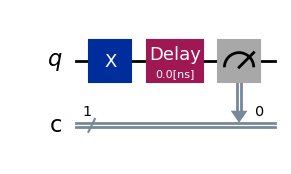

In [22]:
qcs[0].draw('mpl', idle_wires=False, fold=-1)

In [20]:
job = aer_sim.run(qcs, shots=100)
result = job.result()

data = []
for i in result.get_counts():
    if '1' in i:
        data.append(i['1']/100)

Text(0.5, 1.0, 'T1 Experiment on Fake Perth')

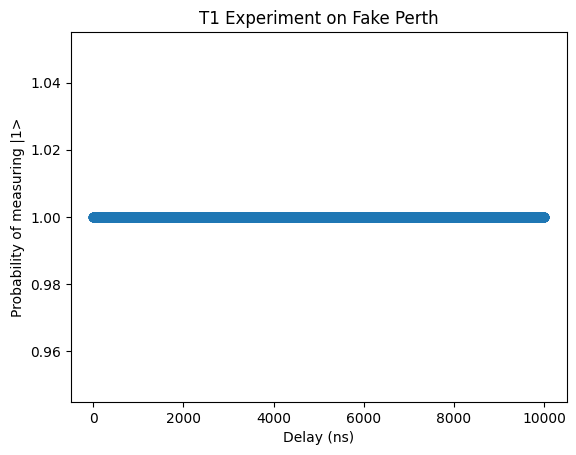

In [21]:
plt.plot(data, marker='o', linestyle='None')
plt.ylabel('Probability of measuring |1>')
plt.xlabel('Delay (ns)')
plt.title('T1 Experiment on Fake Perth')

<h1>T1 on real Backend

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel='ibm_quantum')

backend = service.least_busy(10)
print(f'Using backend: {backend.name}')

pm = generate_preset_pass_manager(backend)

Using backend: ibm_brisbane


In [ ]:
delays = np.arange(0, 1e6, 100).tolist()

qcs = []

for delay in delays:
    qc = QuantumCircuit(1, 1)
    qc.x(0)  # Prepare the qubit in state |1>
    qc.delay(delay, 0, unit='ns')  # Apply a delay
    qc.measure(0, 0)
    qcs.append(qc)



<h1> Simulation of Rabi Oscillations

In [29]:
backend = FakePerth()
sim = AerSimulator.from_backend(backend=backend)
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

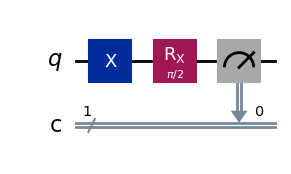

In [ ]:
# Rabi oscillation experiment

qcs = []
for delay in delays:
    qc = QuantumCircuit(1, 1)
    qc.x(0)  # Prepare the qubit in state |1>
    qc.rx(np.pi, 0)  # Apply a rotation
    # qc.delay(delay, 0, unit='ns')  # Apply a delay
    qc.measure(0, 0)
    pm.run(qc)
    qcs.append(qc)

qcs[0].draw('mpl', idle_wires=False, fold=-1)
# job = sim.run(qcs, shots=100)
# result = job.result()
# data = []
# for i in result.get_counts():
#     if '1' in i:
#         data.append(i['1']/100)

# plt.plot(data, marker='o', linestyle='None')